# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\HP\Downloads\zomato.csv\zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Basic Analysis

In [4]:
print(df.columns)

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


In [5]:
df['rate'].head()


0    4.1/5
1    4.1/5
2    3.8/5
3    3.7/5
4    3.8/5
Name: rate, dtype: object

In [6]:

df['cuisines'].value_counts().head()

cuisines
North Indian             2913
North Indian, Chinese    2385
South Indian             1828
Biryani                   918
Bakery, Desserts          911
Name: count, dtype: int64

In [7]:

df['votes'].describe()


count    51717.000000
mean       283.697527
std        803.838853
min          0.000000
25%          7.000000
50%         41.000000
75%        198.000000
max      16832.000000
Name: votes, dtype: float64

In [8]:
total_orders = df.shape[0]
print("Total Orders:", total_orders)

Total Orders: 51717


# Bottleneck Detection

In [25]:
df['rate'] = df['rate'].astype(str)  # convert everything to string

df['rate'] = df['rate'].str.replace('/5', '')


df['rate'] = df['rate'].replace(['NEW', '-', 'nan'], np.nan)


df['rate'] = df['rate'].astype(float)

In [26]:
low_rating = df[df['rate'] < 3.5]
low_rating.head(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
19,https://www.zomato.com/bangalore/360-atoms-res...,"47, 48 &49, 3Rd Floor, 21st Main Road, 2nd Sta...",360 Atoms Restaurant And Cafe,Yes,No,3.1,13,+91 9880594520,Banashankari,Cafe,NaN,"Cafe, Chinese, Continental, Italian",400,"[('Rated 5.0', 'RATED\n Friendly staffs , nic...",[],Cafes,Banashankari
20,https://www.zomato.com/bangalore/the-vintage-c...,"146, 50 ft Road, 3rd Phase, 3rd Stage, Near Ka...",The Vintage Cafe,Yes,No,3.0,62,+91 9880016665\r\n+91 8217311687,Banashankari,Cafe,"Burgers, Caramel Milkshake, Iced Coffee, Iced Tea","Cafe, French, North Indian",400,"[('Rated 2.0', ""RATED\n This is a tiny cafÃ\...",[],Cafes,Banashankari
25,https://www.zomato.com/bangalore/cafe-nova-ban...,"101, Water Tank Road, 2nd Block, 3rd Stage, Ba...",CAFE NOVA,No,No,3.2,11,+91 8971090261,Banashankari,Cafe,NaN,"Cafe, Bakery",600,"[('Rated 1.0', ""RATED\n No ventilation. Smoke...",[],Cafes,Banashankari
27,https://www.zomato.com/bangalore/sea-green-caf...,"1036, Srinidhi Plaza, 3rd floor, Above Nilgiri...",Sea Green Cafe,No,No,3.3,4,+91 9008628448,Banashankari,Cafe,NaN,"Cafe, Fast Food, Beverages",500,"[('Rated 5.0', 'RATED\n Newly opened cafe nea...",[],Cafes,Banashankari
28,https://www.zomato.com/bangalore/cuppa-1-banas...,"940, Shantha Complex, 20th Main, 2nd Stage, Ba...",Cuppa,No,No,3.3,23,+91 9591111123,Banashankari,Cafe,NaN,"Cafe, Fast Food",550,"[('Rated 1.5', 'RATED\n This place was good t...",[],Cafes,Banashankari


# Visualisation

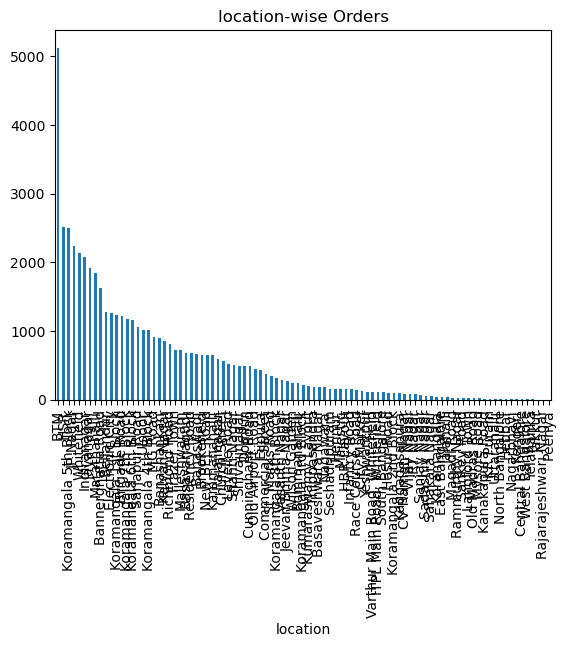

In [9]:
location_orders= df.groupby('location').size().sort_values(ascending=False)

location_orders.plot(kind='bar', title="location-wise Orders")
plt.show()

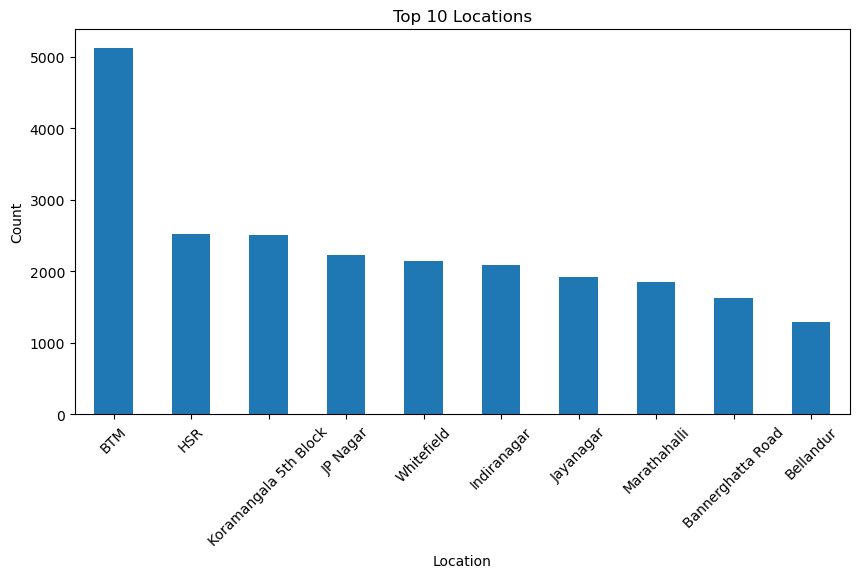

In [10]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel("Location")
plt.ylabel("Count")
plt.title("Top 10 Locations")
plt.show()

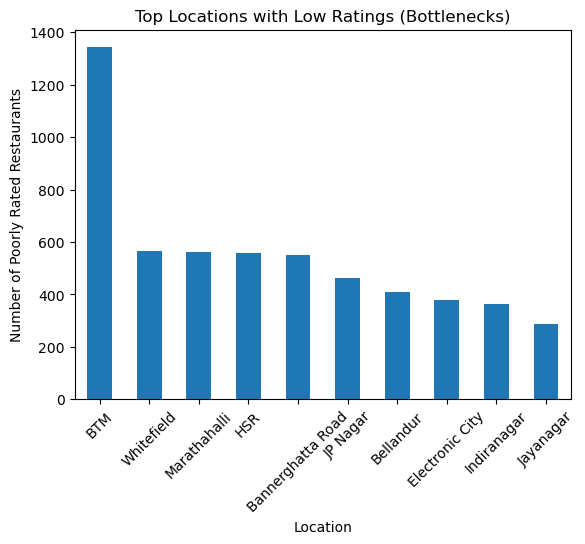

In [27]:
low_rating = df[df['rate'] < 3.5]

low_rating.groupby('location').size().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Locations with Low Ratings (Bottlenecks)")
plt.xlabel("Location")
plt.ylabel("Number of Poorly Rated Restaurants")
plt.xticks(rotation=45)
plt.show()

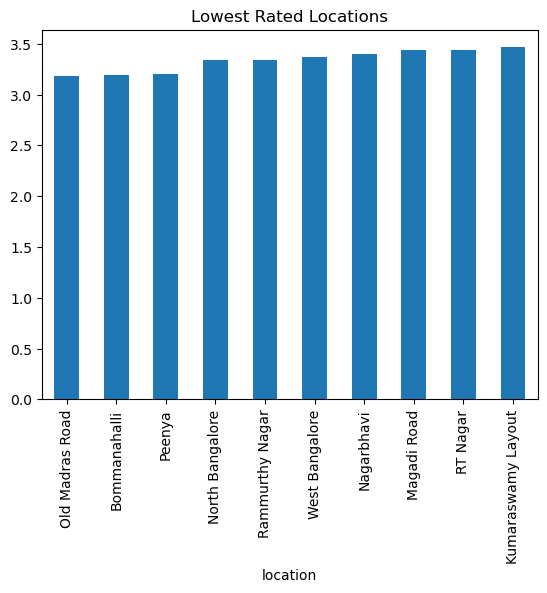

In [28]:
location_rating = df.groupby('location')['rate'].mean().sort_values()

location_rating.head(10).plot(kind='bar')
plt.title("Lowest Rated Locations")
plt.show()

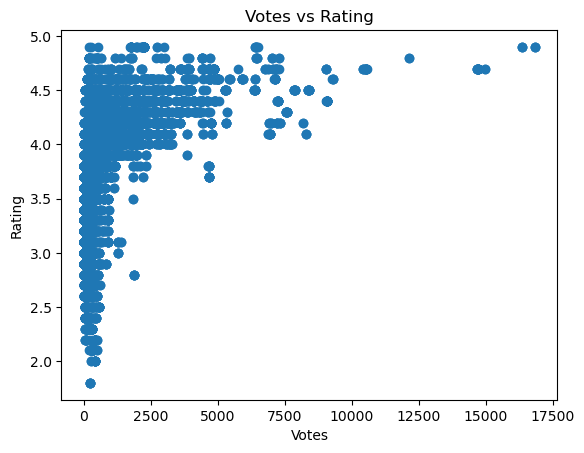

In [29]:
plt.scatter(df['votes'], df['rate'])
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()

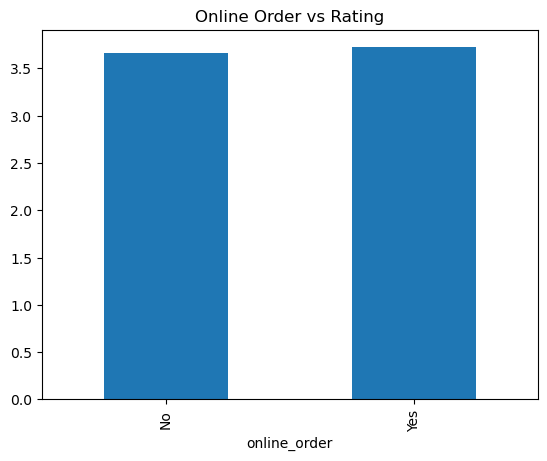

In [30]:
online = df.groupby('online_order')['rate'].mean()

online.plot(kind='bar')
plt.title("Online Order vs Rating")
plt.show()